In [1]:
import numpy as np
import meqpy
import matplotlib.pyplot as plt

## Load Sites and Orbital Vectors

In [5]:
# read xyz file
def read_xyz(filename) -> list:
    with open(filename, "r") as f:
        lines = f.readlines()

    atoms = []
    for line in lines[2:]:
        parts = line.split()
        if len(parts) < 4:
            continue
        elem = parts[0]
        x, y, z = map(float, parts[1:4])
        atoms.append((elem, np.array([x, y, z])))

    return atoms

In [ ]:
# read sites of carbon atoms
atoms = read_xyz("pentacene.xyz")
sites = np.array([pos for elem, pos in atoms if elem == "C"])

# create Cube_2pz object for HOMO orbital
homo_vec = np.loadtxt("pentacene_HOMO.dat")
homo = meqpy.Cube_2pz(sites, homo_vec)

# create Cube_2pz object for LUMO orbital
lumo_vec = np.loadtxt("pentacene_LUMO.dat")
lumo = meqpy.Cube_2pz(sites, lumo_vec)

## Build ``Molecule`` system

In [ ]:
pentacene = meqpy.Molecule(hwhm=0.02, kappa_mode="10")

# add states to molecule
states = [
    meqpy.State(label="GS", energy=0.0, charge=0, multiplicity=1),
    meqpy.State(label="D0-", energy=0.8, charge=-1, multiplicity=2),
    meqpy.State(label="D0+", energy=0.4, charge=+1, multiplicity=2),
]

pentacene.states = states

# add dyson orbitals to charging transitions
# do not center coordinate system around molecule
pentacene.add_dyson("GS", "D0+", meqpy.Dyson(homo, slice_height=9.0, center_mass=False))
pentacene.add_dyson("GS", "D0-", meqpy.Dyson(lumo, slice_height=9.0, center_mass=False))

## Define Junction and calculate coupling to sample

In [144]:
# define system
pentacene.tip_radius = 3.0  # Å
sample_distance = 3.0  # Å

# -----------------------------------------------------------------

# coupling to sample
Ws = pentacene.charging_rates(z=sample_distance, bias=0.0)

# measurement operator: tunneling current
current_matrix = (
    pentacene.dQ * Ws * 1.6022e-19
)  # change to: meqpy.constants.elementary_charges

## I(V) curves

In [ ]:
# tip height, lateral position and bias voltages
tip_height = 12.5  # Å
point_cartesian = (10.0, 11.0)  # lateral tip position in Å
bias_voltage = np.linspace(-1.2, 1.2, 200)  # V

# -----------------------------------------------------------------

point_indices = pentacene.get_xy_indices(point_cartesian)

# coupling to tip
Wt_point = pentacene.charging_rates_pointspec(point_indices, tip_height, bias_voltage)

# combine all rates (tip + sample) and solve master equation
W_point = Wt_point + Ws
Ps_point = meqpy.solve_equilibrium_nd(W_point)

# apply measurement operator and convert to nA
iv_current = meqpy.measurement(current_matrix, Ps_point) * 1e9

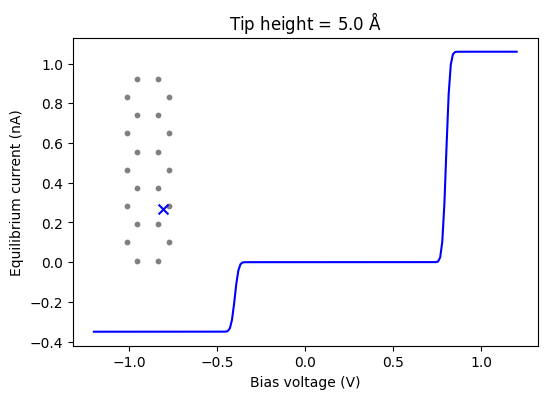

In [149]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(bias_voltage, iv_current, color="blue")
ax.set_xlabel("Bias voltage (V)")
ax.set_ylabel("Equilibrium current (nA)")
ax.set_title(f"Tip height = ${tip_height - np.mean(sites[:, 2]):.1f}$ Å")

# inset
axins = fig.add_axes([0.0, 0.3, 0.5, 0.5])  # adjust as needed
axins.scatter(sites[:, 0], sites[:, 1], color="gray", s=10, clip_on=False)
axins.scatter(*point_cartesian, color="blue", s=50, marker="x")
axins.set_aspect("equal", adjustable="box")
axins.set_xticks([])
axins.set_yticks([])
for spine in axins.spines.values():
    spine.set_visible(False)

plt.show()

## I(x,y) constant-height maps

In [ ]:
# tip height and bias voltages
bias_voltage = -0.6  # V
tip_height = 12.5  # Å

# ------------------------------------------------------------------------

# coupling to tip
Wt = pentacene.charging_rates_dyson(tip_height, bias_voltage)

# combine all rates (tip + sample) and solve master equation
W_map = Wt + Ws
Ps_map = meqpy.solve_equilibrium_nd(W_map)

# apply measurement operator and convert to nA
Ieq_map = meqpy.measurement(current_matrix, Ps_map) * 1e9

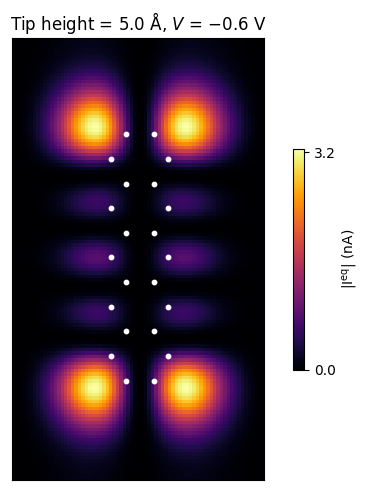

In [ ]:
x_min, x_max = np.min(pentacene.x), np.max(pentacene.x)
y_min, y_max = np.min(pentacene.y), np.max(pentacene.y)

plt.figure(figsize=(6, 5))
plt.imshow(
    np.abs(Ieq_map.T),
    extent=[x_min, x_max, y_min, y_max],
    origin="lower",
    cmap="inferno",
    aspect="equal",
)
min_tick = np.floor(np.abs(Ieq_map).min() * 10) / 10
max_tick = np.floor(np.abs(Ieq_map).max() * 10) / 10
cbar = plt.colorbar(label=r"|I$^{\mathrm{eq}}$| (nA)", shrink=0.5)
cbar.set_ticks([min_tick, max_tick])
plt.scatter(sites[:, 0], sites[:, 1], color="white", s=10)
plt.title(
    rf"Tip height = ${tip_height - np.mean(sites[:, 2]):.1f}$ Å, $V$ = ${bias_voltage:.1f}$ V"
)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()